In [1]:
import yfinance as yf
import pandas as pd

print("yfinance:", yf.__version__)
print("pandas:", pd.__version__)

yfinance: 1.5.1
pandas: 3.0.3


In [2]:
dati = yf.download("SPY", start="2020-01-01", auto_adjust=True)

print(dati.shape)
dati.head()

[*********************100%***********************]  1 of 1 completed

(1637, 5)


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.125275,296.143523,293.992323,294.912966,59151200
2020-01-03,293.882935,295.004113,292.688847,292.743535,77709700
2020-01-06,295.004181,295.086214,292.014370,292.132872,55653900
2020-01-07,294.174622,294.912950,293.727958,294.438942,40496400
2020-01-08,295.742462,296.954771,294.119959,294.366059,68296000


In [3]:
print(dati.columns)
print(dati.index.min(), "→", dati.index.max())
print(dati.isna().sum())

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])
2020-01-02 00:00:00 → 2026-07-09 00:00:00
Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'SPY — prezzo aggiustato dal 2020'}, xlabel='Date'>

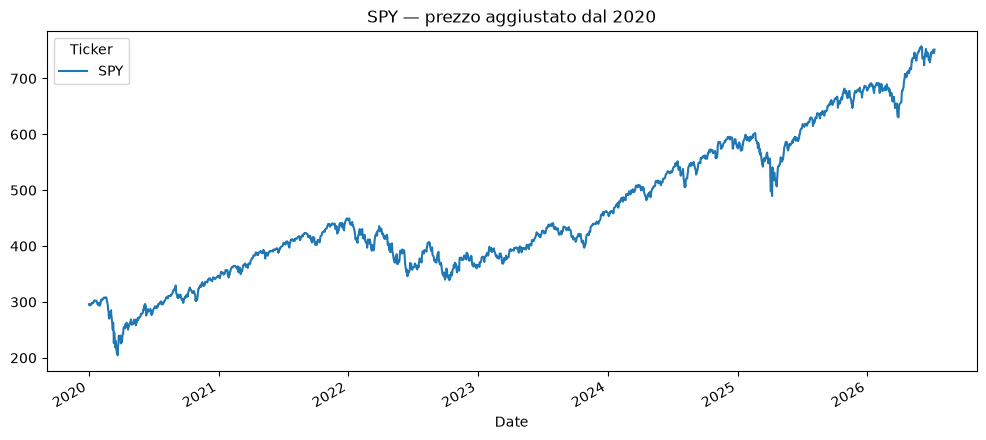

In [4]:
dati["Close"].plot(figsize=(12, 5), title="SPY — prezzo aggiustato dal 2020")

In [5]:
print("Prima:", dati.columns)

if isinstance(dati.columns, pd.MultiIndex):
    dati.columns = dati.columns.droplevel("Ticker")

print("Dopo:", dati.columns)

Prima: MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])
Dopo: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [6]:
prezzi = dati["Close"]
rend = prezzi.pct_change().dropna()

print(type(rend))
print(rend.shape)
rend.head()

<class 'pandas.Series'>
(1636,)


Date
2020-01-03   -0.007572
2020-01-06    0.003815
2020-01-07   -0.002812
2020-01-08    0.005330
2020-01-09    0.006781
Name: Close, dtype: float64

In [7]:
print("Periodo:", rend.index.min().date(), "→", rend.index.max().date())
print("Giorni di borsa:", len(rend))
print()
print("Rendimento medio giornaliero:", round(rend.mean() * 100, 4), "%")
print("Peggior giorno:", round(rend.min() * 100, 2), "% il", rend.idxmin().date())
print("Miglior giorno:", round(rend.max() * 100, 2), "% il", rend.idxmax().date())

Periodo: 2020-01-03 → 2026-07-09
Giorni di borsa: 1636

Rendimento medio giornaliero: 0.0651 %
Peggior giorno: -10.94 % il 2020-03-16
Miglior giorno: 10.5 % il 2025-04-09


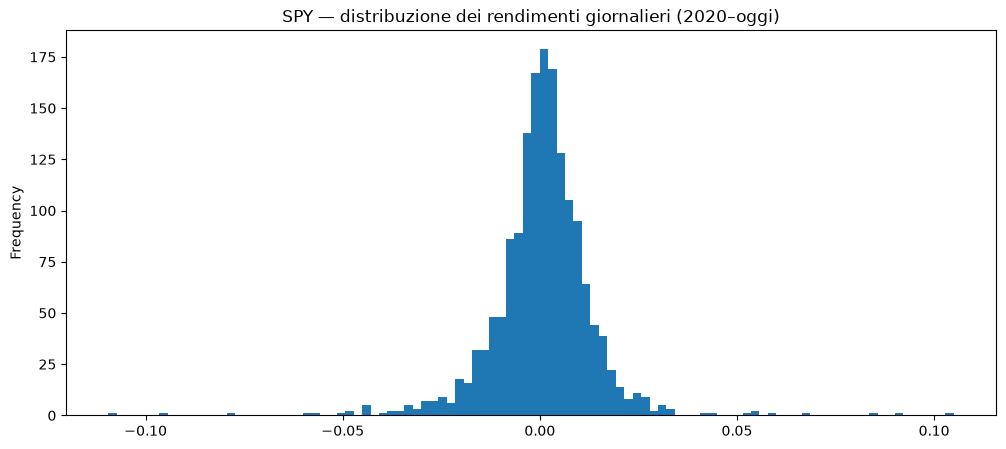

In [8]:
rend.plot(kind="hist", bins=100, figsize=(12, 5),
          title="SPY — distribuzione dei rendimenti giornalieri (2020–oggi)");

In [9]:
import numpy as np

GIORNI_BORSA = 252

vol_giornaliera = rend.std()
vol_annua = vol_giornaliera * np.sqrt(GIORNI_BORSA)

anni = len(rend) / GIORNI_BORSA
cagr = (prezzi.iloc[-1] / prezzi.iloc[0]) ** (1 / anni) - 1

print(f"Periodo: {rend.index.min().date()} → {rend.index.max().date()} ({anni:.2f} anni)")
print(f"Volatilità annualizzata: {vol_annua * 100:.2f}%")
print(f"Rendimento annualizzato (CAGR): {cagr * 100:.2f}%")

Periodo: 2020-01-03 → 2026-07-09 (6.49 anni)
Volatilità annualizzata: 20.29%
Rendimento annualizzato (CAGR): 15.43%


In [10]:
RF_ANNUO = 0.00   # ← il tasso privo di rischio. Vedi discussione sotto.

rf_giornaliero = (1 + RF_ANNUO) ** (1 / GIORNI_BORSA) - 1
excess = rend - rf_giornaliero
sharpe = excess.mean() / excess.std() * np.sqrt(GIORNI_BORSA)

print(f"Sharpe ratio: {sharpe:.2f}")
print(f"  calcolato su: SPY, prezzi Close aggiustati (total return)")
print(f"  periodo: {rend.index.min().date()} → {rend.index.max().date()}")
print(f"  risk-free assunto: {RF_ANNUO*100:.2f}% annuo, valuta USD")
print(f"  annualizzazione: sqrt(252), rendimenti giornalieri")

Sharpe ratio: 0.81
  calcolato su: SPY, prezzi Close aggiustati (total return)
  periodo: 2020-01-03 → 2026-07-09
  risk-free assunto: 0.00% annuo, valuta USD
  annualizzazione: sqrt(252), rendimenti giornalieri


In [11]:
for inizio, fine in [("2020-01-01", "2026-12-31"),
                     ("2020-01-01", "2021-12-31"),
                     ("2022-01-01", "2022-12-31"),
                     ("2023-01-01", "2026-12-31")]:
    r = rend.loc[inizio:fine]
    s = r.mean() / r.std() * np.sqrt(GIORNI_BORSA)
    v = r.std() * np.sqrt(GIORNI_BORSA)
    print(f"{inizio} → {fine}:  Sharpe {s:5.2f}   vol {v*100:5.1f}%   ({len(r)} giorni)")

2020-01-01 → 2026-12-31:  Sharpe  0.81   vol  20.3%   (1636 giorni)
2020-01-01 → 2021-12-31:  Sharpe  0.94   vol  25.4%   (504 giorni)
2022-01-01 → 2022-12-31:  Sharpe -0.71   vol  24.2%   (251 giorni)
2023-01-01 → 2026-12-31:  Sharpe  1.44   vol  15.1%   (881 giorni)


In [12]:
media_aritmetica_giorno = rend.mean()
media_geometrica_giorno = (prezzi.iloc[-1] / prezzi.iloc[0]) ** (1 / len(rend)) - 1
drag_teorico = rend.std() ** 2 / 2

print(f"Media aritmetica giornaliera: {media_aritmetica_giorno*100:.4f}%")
print(f"Media geometrica giornaliera: {media_geometrica_giorno*100:.4f}%")
print(f"Differenza (osservata):       {(media_aritmetica_giorno - media_geometrica_giorno)*100:.4f}%")
print(f"Differenza (prevista, σ²/2):  {drag_teorico*100:.4f}%")

Media aritmetica giornaliera: 0.0651%
Media geometrica giornaliera: 0.0570%
Differenza (osservata):       0.0082%
Differenza (prevista, σ²/2):  0.0082%


In [13]:
curva = (1 + rend).cumprod()
picco = curva.cummax()
drawdown = curva / picco - 1

mdd = drawdown.min()
data_fondo = drawdown.idxmin()
data_picco = curva.loc[:data_fondo].idxmax()

print(f"Max drawdown: {mdd*100:.2f}%")
print(f"  picco:  {data_picco.date()}")
print(f"  fondo:  {data_fondo.date()}")
print(f"  durata discesa: {(data_fondo - data_picco).days} giorni solari")

Max drawdown: -33.72%
  picco:  2020-02-19
  fondo:  2020-03-23
  durata discesa: 33 giorni solari


<Axes: title={'center': 'SPY — drawdown dal massimo precedente (max -33.7%)'}, xlabel='Date'>

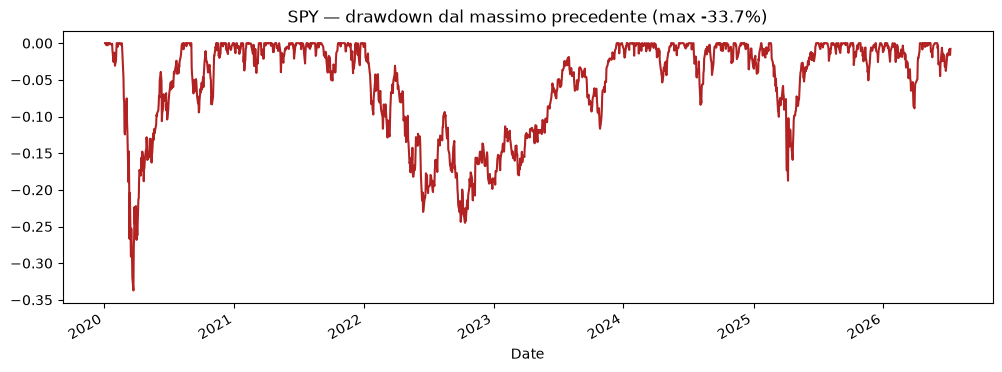

In [14]:
drawdown.plot(figsize=(12, 4), color="firebrick",
              title=f"SPY — drawdown dal massimo precedente (max {mdd*100:.1f}%)")

In [15]:
def metriche(ticker, inizio="2020-01-01", fine=None, rf_annuo=0.0):
    """Scarica un ticker e ne calcola le metriche di rischio/rendimento.
    Restituisce un dizionario. Non giudica: misura."""

    dati = yf.download(ticker, start=inizio, end=fine,
                       auto_adjust=True, progress=False)

    if isinstance(dati.columns, pd.MultiIndex):
        dati.columns = dati.columns.droplevel("Ticker")

    prezzi = dati["Close"].dropna()
    if len(prezzi) < 30:
        raise ValueError(f"{ticker}: solo {len(prezzi)} giorni. Ticker sbagliato?")

    rend = prezzi.pct_change().dropna()
    anni = len(rend) / GIORNI_BORSA

    vol = rend.std() * np.sqrt(GIORNI_BORSA)
    cagr = (prezzi.iloc[-1] / prezzi.iloc[0]) ** (1 / anni) - 1

    rf_g = (1 + rf_annuo) ** (1 / GIORNI_BORSA) - 1
    excess = rend - rf_g
    sharpe = excess.mean() / excess.std() * np.sqrt(GIORNI_BORSA)

    curva = (1 + rend).cumprod()
    dd = curva / curva.cummax() - 1

    return {
        "ticker": ticker,
        "da": rend.index.min().date(),
        "a": rend.index.max().date(),
        "giorni": len(rend),
        "cagr_%": round(cagr * 100, 2),
        "vol_%": round(vol * 100, 2),
        "sharpe": round(sharpe, 2),
        "max_dd_%": round(dd.min() * 100, 2),
        "giorni_sott_acqua": int((dd < -0.0001).sum()),
        "rf_assunto_%": rf_annuo * 100,
    }

In [16]:
def metriche(ticker, inizio="2020-01-01", fine=None, rf_annuo=0.0):
    """Scarica un ticker e ne calcola le metriche di rischio/rendimento.
    Restituisce un dizionario. Non giudica: misura."""

    dati = yf.download(ticker, start=inizio, end=fine,
                       auto_adjust=True, progress=False)

    if isinstance(dati.columns, pd.MultiIndex):
        dati.columns = dati.columns.droplevel("Ticker")

    prezzi = dati["Close"].dropna()
    if len(prezzi) < 30:
        raise ValueError(f"{ticker}: solo {len(prezzi)} giorni. Ticker sbagliato?")

    rend = prezzi.pct_change().dropna()
    anni = len(rend) / GIORNI_BORSA

    vol = rend.std() * np.sqrt(GIORNI_BORSA)
    cagr = (prezzi.iloc[-1] / prezzi.iloc[0]) ** (1 / anni) - 1

    rf_g = (1 + rf_annuo) ** (1 / GIORNI_BORSA) - 1
    excess = rend - rf_g
    sharpe = excess.mean() / excess.std() * np.sqrt(GIORNI_BORSA)

    curva = (1 + rend).cumprod()
    dd = curva / curva.cummax() - 1

    return {
        "ticker": ticker,
        "da": rend.index.min().date(),
        "a": rend.index.max().date(),
        "giorni": len(rend),
        "cagr_%": round(cagr * 100, 2),
        "vol_%": round(vol * 100, 2),
        "sharpe": round(sharpe, 2),
        "max_dd_%": round(dd.min() * 100, 2),
        "giorni_sott_acqua": int((dd < -0.0001).sum()),
        "rf_assunto_%": rf_annuo * 100,
    }

In [17]:
metriche("SPY", inizio="2020-01-01")

{'ticker': 'SPY',
 'da': datetime.date(2020, 1, 3),
 'a': datetime.date(2026, 7, 9),
 'giorni': 1636,
 'cagr_%': np.float64(15.43),
 'vol_%': np.float64(20.29),
 'sharpe': np.float64(0.81),
 'max_dd_%': np.float64(-33.72),
 'giorni_sott_acqua': 1380,
 'rf_assunto_%': 0.0}

In [18]:
lista = ["SPY", "QQQ", "TLT", "GLD"]
tabella = pd.DataFrame([metriche(t, inizio="2020-01-01") for t in lista])
tabella.set_index("ticker")

,da,a,giorni,cagr_%,vol_%,sharpe,max_dd_%,giorni_sott_acqua,rf_assunto_%
ticker,,,,,,,,,
SPY,2020-01-03,2026-07-09,1636,15.43,20.29,0.81,-33.72,1380,0.0
QQQ,2020-01-03,2026-07-09,1636,21.16,25.02,0.89,-35.12,1417,0.0
TLT,2020-01-03,2026-07-09,1636,-4.42,16.64,-0.19,-48.35,1614,0.0
GLD,2020-01-03,2026-07-09,1636,16.04,18.28,0.91,-26.21,1490,0.0


In [19]:
coppia = ["SPY", "ESGU"]
grezzi = yf.download(coppia, start="2017-01-01", auto_adjust=True, progress=False)

prezzi2 = grezzi["Close"].dropna()

print(prezzi2.columns.tolist())
print("Righe dopo dropna:", len(prezzi2))
print("Periodo:", prezzi2.index.min().date(), "→", prezzi2.index.max().date())
prezzi2.head(3)

['ESGU', 'SPY']
Righe dopo dropna: 2391
Periodo: 2017-01-03 → 2026-07-09


Ticker,ESGU,SPY
Date,,
2017-01-03,42.848213,193.968124
2017-01-04,42.848213,195.122070
2017-01-05,42.848213,194.967056


In [20]:
confronto = pd.DataFrame([metriche(t, inizio="2017-01-01") for t in coppia])
confronto.set_index("ticker")

,da,a,giorni,cagr_%,vol_%,sharpe,max_dd_%,giorni_sott_acqua,rf_assunto_%
ticker,,,,,,,,,
SPY,2017-01-04,2026-07-09,2390,15.35,18.27,0.87,-33.72,2005,0.0
ESGU,2017-01-04,2026-07-09,2390,15.28,18.62,0.86,-33.87,1966,0.0


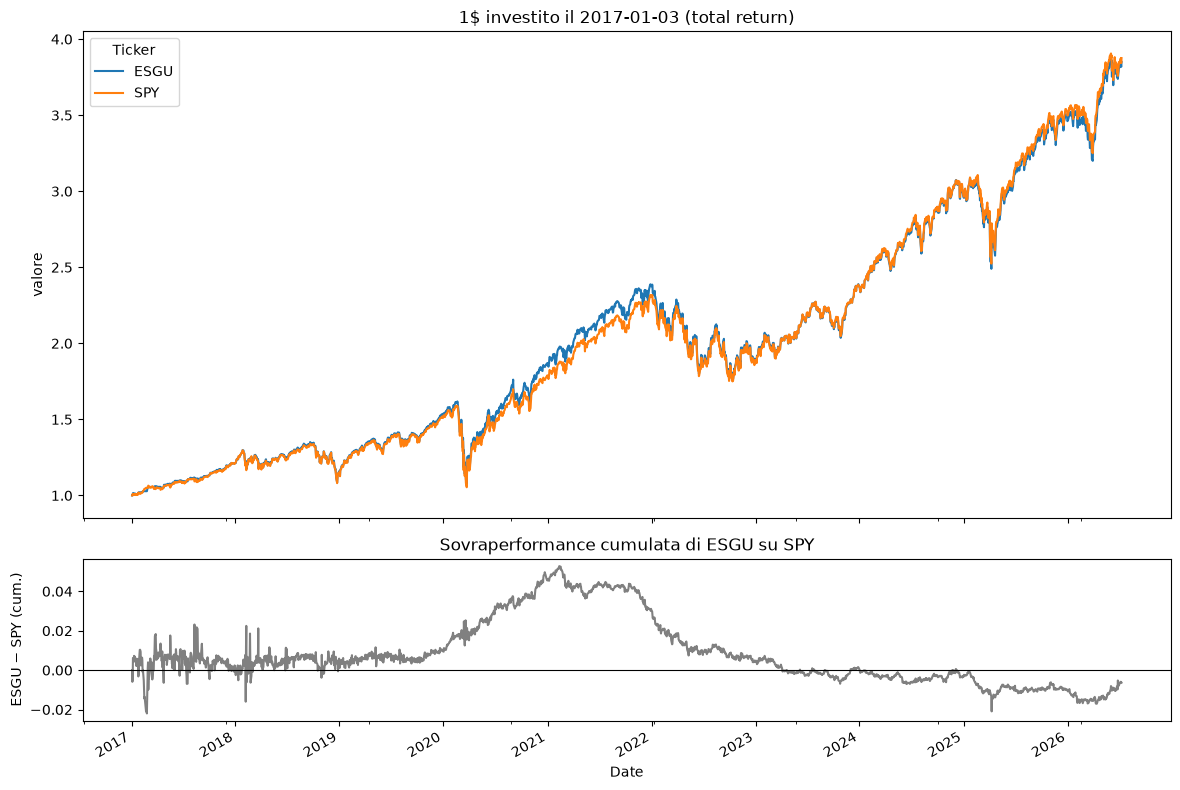

In [21]:
import matplotlib.pyplot as plt

norm = prezzi2 / prezzi2.iloc[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})

norm.plot(ax=ax[0], title="1$ investito il 2017-01-03 (total return)")
ax[0].set_ylabel("valore")

(norm["ESGU"] / norm["SPY"] - 1).plot(ax=ax[1], color="grey")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_ylabel("ESGU − SPY (cum.)")
ax[1].set_title("Sovraperformance cumulata di ESGU su SPY")
plt.tight_layout()

In [22]:
rend2 = prezzi2.pct_change().dropna()
corr = rend2["SPY"].corr(rend2["ESGU"])
te = (rend2["ESGU"] - rend2["SPY"]).std() * np.sqrt(GIORNI_BORSA)

print(f"Correlazione dei rendimenti giornalieri: {corr:.4f}")
print(f"Tracking error annualizzato: {te*100:.2f}%")
print(f"Beta di ESGU su SPY: {rend2['ESGU'].cov(rend2['SPY']) / rend2['SPY'].var():.3f}")

Correlazione dei rendimenti giornalieri: 0.9811
Tracking error annualizzato: 3.61%
Beta di ESGU su SPY: 1.000


In [23]:
fermi = (rend2 == 0)
print("Giorni a rendimento esattamente zero, per anno:")
print(fermi.groupby(rend2.index.year).sum())

Giorni a rendimento esattamente zero, per anno:
Ticker  ESGU  SPY
Date             
2017     123    1
2018       5    2
2019       0    0
2020       1    0
2021       3    0
2022       1    1
2023       2    1
2024       0    0
2025       0    0
2026       1    0


In [24]:
for inizio, fine, etichetta in [("2017-01-01", "2018-12-31", "ESGU illiquido"),
                                ("2019-01-01", "2026-12-31", "ESGU liquido")]:
    r = rend2.loc[inizio:fine]
    c = r["SPY"].corr(r["ESGU"])
    t = (r["ESGU"] - r["SPY"]).std() * np.sqrt(GIORNI_BORSA)
    print(f"{etichetta:16s} {inizio[:4]}–{fine[:4]}:  corr {c:.4f}   TE {t*100:.2f}%   ({len(r)} gg)")

ESGU illiquido   2017–2018:  corr 0.8511   TE 7.10%   (501 gg)
ESGU liquido     2019–2026:  corr 0.9962   TE 1.77%   (1889 gg)


In [25]:
annui = (1 + rend2).groupby(rend2.index.year).prod() - 1
tab = (annui * 100).round(2)
tab["diff_pp"] = (tab["ESGU"] - tab["SPY"]).round(2)
tab

Ticker,ESGU,SPY,diff_pp
Date,,,
2017,21.07,20.78,0.29
2018,-4.24,-4.57,0.33
2019,31.72,31.22,0.50
2020,22.54,18.33,4.21
2021,26.89,28.73,-1.84
2022,-20.27,-18.18,-2.09
2023,25.79,26.18,-0.39
2024,24.31,24.89,-0.58
2025,16.90,17.72,-0.82


In [26]:
rel = (1 + rend2["ESGU"]).cumprod() / (1 + rend2["SPY"]).cumprod() - 1

print(f"Massima sovraperformance: {rel.max()*100:.2f}%  il {rel.idxmax().date()}")
print(f"Oggi:                     {rel.iloc[-1]*100:.2f}%")
print(f"Restituito dal picco:     {(rel.max() - rel.iloc[-1])*100:.2f} pp")

Massima sovraperformance: 5.28%  il 2021-02-11
Oggi:                     -0.64%
Restituito dal picco:     5.91 pp


In [27]:
from pathlib import Path
import datetime as dt

Path("dati").mkdir(exist_ok=True)
oggi = dt.date.today().isoformat()
percorso = f"dati/prezzi_SPY_ESGU_{oggi}.csv"
prezzi2.to_csv(percorso)

print("Salvato:", percorso, "—", len(prezzi2), "righe")

Salvato: dati/prezzi_SPY_ESGU_2026-07-10.csv — 2391 righe


In [28]:
def confronta(tickers, inizio="2019-01-01", fine=None, rf_annuo=0.0):
    """Scarica N ticker, li ALLINEA sui giorni comuni, e ne calcola le metriche.
    A differenza di metriche(), garantisce che tutti i numeri vengano
    dallo stesso identico insieme di giorni. Restituisce (tabella, prezzi)."""

    grezzi = yf.download(tickers, start=inizio, end=fine,
                         auto_adjust=True, progress=False)
    px = grezzi["Close"].dropna()          # ← l'allineamento avviene qui

    rend = px.pct_change().dropna()
    anni = len(rend) / GIORNI_BORSA
    rf_g = (1 + rf_annuo) ** (1 / GIORNI_BORSA) - 1

    righe = []
    for t in px.columns:
        r = rend[t]
        curva = (1 + r).cumprod()
        dd = curva / curva.cummax() - 1
        ex = r - rf_g
        righe.append({
            "ticker": t,
            "cagr_%":   round(((px[t].iloc[-1] / px[t].iloc[0]) ** (1/anni) - 1) * 100, 2),
            "vol_%":    round(r.std() * np.sqrt(GIORNI_BORSA) * 100, 2),
            "sharpe":   round(ex.mean() / ex.std() * np.sqrt(GIORNI_BORSA), 2),
            "max_dd_%": round(dd.min() * 100, 2),
            "gg_sott_acqua": int((dd < -0.0001).sum()),
            "zeri":     int((r == 0).sum()),
        })

    tab = pd.DataFrame(righe).set_index("ticker")
    tab.attrs["periodo"] = f"{rend.index.min().date()} → {rend.index.max().date()}"
    tab.attrs["giorni"] = len(rend)
    tab.attrs["rf_%"] = rf_annuo * 100
    tab.attrs["fonte"] = "yahoo / Close auto_adjust"
    return tab, px

In [29]:
tab, px = confronta(["SPY", "ESGU"], inizio="2019-01-01")
print(tab.attrs)
tab

{'periodo': '2019-01-03 → 2026-07-09', 'giorni': 1888, 'rf_%': 0.0, 'fonte': 'yahoo / Close auto_adjust'}


,cagr_%,vol_%,sharpe,max_dd_%,gg_sott_acqua,zeri
ticker,,,,,,
ESGU,17.43,19.84,0.91,-33.87,1577,8
SPY,17.55,19.44,0.93,-33.72,1557,2


In [30]:
for anno in range(2017, 2024):
    t, _ = confronta(["SPY", "ESGU"], inizio=f"{anno}-01-01")
    d_cagr   = t.loc["ESGU", "cagr_%"]  - t.loc["SPY", "cagr_%"]
    d_sharpe = t.loc["ESGU", "sharpe"]  - t.loc["SPY", "sharpe"]
    print(f"da {anno}:  ΔCAGR {d_cagr:+6.2f} pp   ΔSharpe {d_sharpe:+.2f}   ({t.attrs['giorni']} gg)")

da 2017:  ΔCAGR  -0.07 pp   ΔSharpe -0.01   (2390 gg)
da 2018:  ΔCAGR  -0.06 pp   ΔSharpe -0.02   (2139 gg)
da 2019:  ΔCAGR  -0.12 pp   ΔSharpe -0.02   (1888 gg)
da 2020:  ΔCAGR  -0.28 pp   ΔSharpe -0.03   (1636 gg)
da 2021:  ΔCAGR  -1.07 pp   ΔSharpe -0.06   (1383 gg)
da 2022:  ΔCAGR  -0.89 pp   ΔSharpe -0.05   (1131 gg)
da 2023:  ΔCAGR  -0.39 pp   ΔSharpe -0.03   (880 gg)


In [31]:
rng = np.random.default_rng(42)
r = px.pct_change().dropna()
n = len(r)

def sharpe_da(serie):
    return serie.mean() / serie.std() * np.sqrt(GIORNI_BORSA)

osservata = sharpe_da(r["ESGU"]) - sharpe_da(r["SPY"])

diffs = []
for _ in range(2000):
    idx = rng.integers(0, n, n)      # n giorni pescati a caso, CON reimmissione
    camp = r.iloc[idx]               # righe intere: la coppia ESGU/SPY resta appaiata
    diffs.append(sharpe_da(camp["ESGU"]) - sharpe_da(camp["SPY"]))
diffs = np.array(diffs)

print(f"ΔSharpe osservato:        {osservata:+.3f}")
print(f"Intervallo 5°–95° perc.:  {np.percentile(diffs, 5):+.3f} → {np.percentile(diffs, 95):+.3f}")
print(f"Quante volte ESGU vince:  {(diffs > 0).mean()*100:.1f}% dei campioni")

ΔSharpe osservato:        -0.020
Intervallo 5°–95° perc.:  -0.071 → +0.031
Quante volte ESGU vince:  28.3% dei campioni


In [32]:
import sys
print("Python:", sys.version.split()[0])
for m in (pd, np, yf):
    print(f"{m.__name__}: {m.__version__}")
print("Snapshot dati:", percorso)

Python: 3.14.6
pandas: 3.0.3
numpy: 2.5.1
yfinance: 1.5.1
Snapshot dati: dati/prezzi_SPY_ESGU_2026-07-10.csv


In [33]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [34]:
!ls -lh requirements.txt
!head -5 requirements.txt
!wc -l requirements.txt

-rw-r--r--  1 carlospinetto  staff   2,1K 10 Lug 10:54 requirements.txt
anyio==4.14.1
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
     117 requirements.txt


In [35]:
GIORNI_BORSA = 252

def confronta(tickers, inizio="2019-01-01", fine=None, rf_annuo=0.0):
    grezzi = yf.download(tickers, start=inizio, end=fine, auto_adjust=True, progress=False)
    px = grezzi["Close"].dropna()
    rend = px.pct_change().dropna()
    anni = len(rend) / GIORNI_BORSA
    rf_g = (1 + rf_annuo) ** (1 / GIORNI_BORSA) - 1
    righe = []
    for t in px.columns:
        r = rend[t]; curva = (1 + r).cumprod(); dd = curva / curva.cummax() - 1; ex = r - rf_g
        righe.append({
            "ticker": t,
            "cagr_%":   round(((px[t].iloc[-1] / px[t].iloc[0]) ** (1/anni) - 1) * 100, 2),
            "vol_%":    round(r.std() * np.sqrt(GIORNI_BORSA) * 100, 2),
            "sharpe":   round(ex.mean() / ex.std() * np.sqrt(GIORNI_BORSA), 2),
            "max_dd_%": round(dd.min() * 100, 2),
            "gg_sott_acqua": int((dd < -0.0001).sum()),
            "zeri":     int((r == 0).sum()),
        })
    tab = pd.DataFrame(righe).set_index("ticker")
    tab.attrs["periodo"] = f"{rend.index.min().date()} → {rend.index.max().date()}"
    tab.attrs["giorni"] = len(rend)
    tab.attrs["rf_%"] = rf_annuo * 100
    tab.attrs["fonte"] = "yahoo / Close auto_adjust"
    return tab, px